In [1]:
#maybe dont run this on your system...
!mamba install fastcore=1.5.29 

warning  libmamba 'repo.anaconda.com', a commercial channel hosted by Anaconda.com, is used.
    
warning  libmamba Please make sure you understand Anaconda Terms of Services.
    
warning  libmamba See: https://legal.anaconda.com/policies/en/
[+] 0.0s
[+] 0.1s
pkgs/main/noarch ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/main/osx-64 ━━━━━━━━╸━━━━━━━━━━━━━━━╸━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/r/noarch    ━━━━━━━━━━╸━━━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/r/osx-64    ━━━━━━━╸━━━━━━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
Pinned packages:

  - python=3.10


Transaction

  Prefix: /Users/zoe/.local/share/mamba/envs/tapas-upgrade

  All requested packages already installed


Transaction starting
[+] 0.0s

Transaction finished



In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["SYNTHCITY_DEVICE"] = "cpu"

import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.tapas.tapas_data_processors import AdultDataProcessor
import random



from reprosyn.methods import DS_PRIVBAYES
from reprosyn.methods import DS_BAYNET
from utils.generators import BenchmarkGenerator, SynthcityGenerator, ReprosynGenerator, Raw

/Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
gen1 = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)
repr(gen1)

'PrivBayes_epsilon=1.0'

In [4]:
gen2 = SynthcityGenerator("uniform_sampler", label="uniform_sampler")
repr(gen2)

'uniform_sampler_random_state=42'

In [5]:
gen3 = Raw()
repr(gen3)

'Raw'

In [3]:
# !pip install tf_keras

4522
estimating categorical probs
estimating approx kdes(histogram)
[0.9035398230088496]
Attacking : PrivBayes_epsilon=1.0
Generate datasets
[True, False, False, True, False, True, False, True, False, True, False, True, True, False, False, True, False, True, True, False, False, True, True, False, True, False, False, True, False, True, True, False, False, True, True, False, False, True, False, True, False, True, False, True, False, True, False, True, True, False]
COMPLEXITY:  2
COMPLEXITY:  10
COMPLEXITY:  20
COMPLEXITY:  50


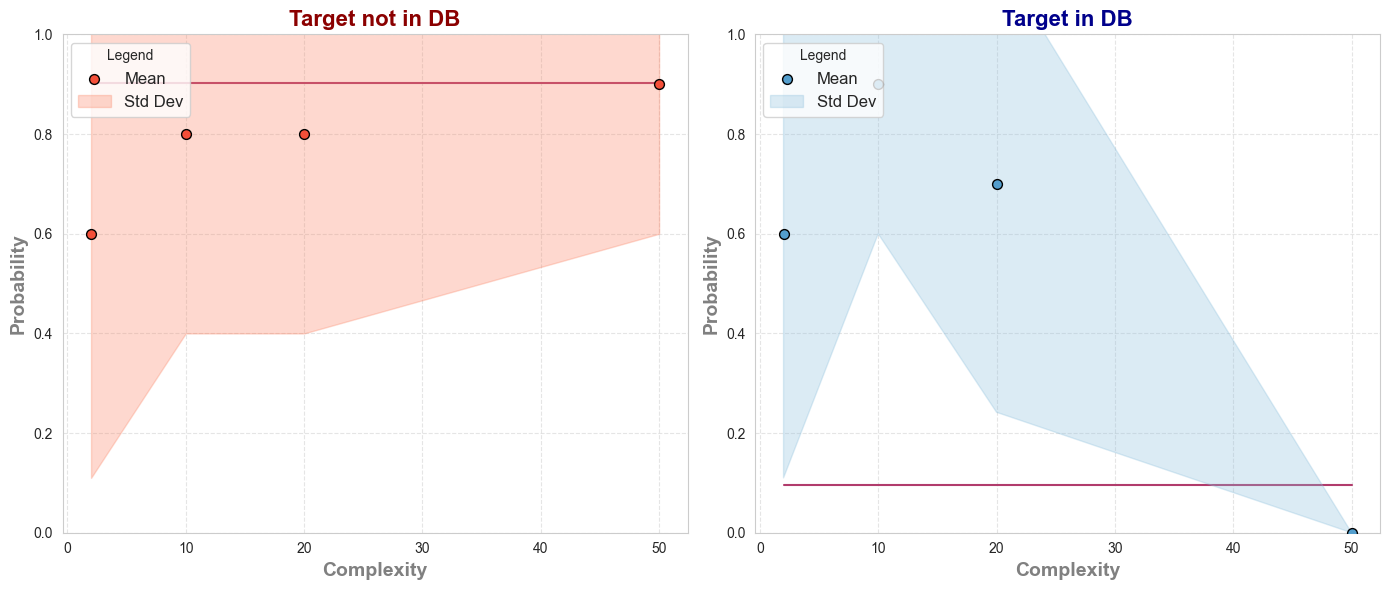

In [6]:
#TEST PIPELINE
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.1)  #downsample the data 
print(len(data.data))
ind = [int(random.random() * len(data.data))]

target_record = data.get_records(ind)
data.drop_records(ind, in_place=True)

attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2000))


pipeline = BenchmarkPipeline(data, attack, [gen1], target_record=target_record)
pipeline.run([2,10,20,50], 10, 2)

In [19]:
data.label

'data/adult'

In [10]:
data.description.schema

[{'name': 'age',
  'type': 'Integer',
  'representation': 'number',
  'min': 0,
  'max': 90},
 {'name': 'workclass',
  'type': 'finite',
  'representation': ['Private',
   'Self-emp-not-inc',
   'Self-emp-inc',
   'Federal-gov',
   'Local-gov',
   'State-gov',
   'Without-pay']},
 {'name': 'fnlwgt',
  'type': 'Float',
  'representation': 'number',
  'min': 13492.0,
  'max': 1490400.0},
 {'name': 'education',
  'type': 'finite',
  'representation': ['Bachelors',
   'Some-college',
   '11th',
   'HS-grad',
   'Prof-school',
   'Assoc-acdm',
   'Assoc-voc',
   '9th',
   '7th-8th',
   '12th',
   'Masters',
   '1st-4th',
   '10th',
   'Doctorate',
   '5th-6th',
   'Preschool']},
 {'name': 'education-num',
  'type': 'Integer',
  'representation': 'number',
  'min': 1,
  'max': 16},
 {'name': 'marital-status',
  'type': 'finite',
  'representation': ['Married-civ-spouse',
   'Divorced',
   'Never-married',
   'Separated',
   'Widowed',
   'Married-spouse-absent',
   'Married-AF-spouse']},
 {'

In [ ]:
col_dic = {}
for col in data.description.schema:
    name = col['name']
    dtype = col['type']
    representation = col['representation']
    
    if



In [20]:
dic = {data.label : {}}
dic

{'data/adult': {}}

In [13]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframe(
    data=data.data,
    table_name='adult')

In [14]:
metadata

{
    "tables": {
        "adult": {
            "columns": {
                "age": {
                    "sdtype": "numerical"
                },
                "workclass": {
                    "sdtype": "categorical"
                },
                "fnlwgt": {
                    "sdtype": "numerical"
                },
                "education": {
                    "sdtype": "categorical"
                },
                "education-num": {
                    "sdtype": "numerical"
                },
                "marital-status": {
                    "sdtype": "categorical"
                },
                "occupation": {
                    "sdtype": "categorical"
                },
                "relationship": {
                    "sdtype": "categorical"
                },
                "race": {
                    "sdtype": "categorical"
                },
                "sex": {
                    "sdtype": "categorical"
                },
           